# Feature Sufficiency in Alzheimer's Disease Prediction
## A Systematic Evaluation Across Statistically and Clinically Motivated Feature Sets

**Course:** AT82.01 Computer Programming for Data Science and Artificial Intelligence  
**Authors:** Phung Van Thai (st126392) | Theingi Win (st126358)  
**Instructor:** Professor Sein Minn | TA: Rakshya Lama Moktan

---

## Research Questions

- **RQ1:** What is the minimum clinically accessible feature set sufficient for reliable AD screening, and how does predictive performance degrade as feature availability decreases from specialist to community settings?
- **RQ2:** Do statistically motivated and clinically motivated feature selection strategies converge on the same irreducible predictors?

## Hypotheses (pre-registered before modeling)

| ID | Hypothesis |
|----|-----------|
| H1 | The 5 consensus predictors account for a disproportionate share of predictive power — removing remaining features produces negligible performance loss |
| H2 | Performance degrades as feature availability decreases, with the sharpest drop when cognitive/functional assessments are removed |
| H3 | Degradation is non-linear: Full→Primary Care drop is modest; further restriction to Community Minimum is more substantial |
| H4 | Consensus High Signal (5 features, statistical) ≈ Cognitive Only (3 features, clinical), validating EDA↔clinical convergence |

---

## Workflow Overview

```
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
   2a. Target distribution
   2b. Correlation heatmap
   2c. Mutual Information
   2d. Random Forest importance
   2e. Chi-Square tests
   2f. Logistic Regression coefficients
   2g. Cognitive feature boxplots
3. Feature Set Construction (6 sets × 3 tiers)
4. Preprocessing Pipeline
5. Model Training (RF + XGBoost + LR) with Stratified 10-Fold CV + SMOTE
6. Results & Evaluation
   6a. Summary table
   6b. Grouped bar chart (4 metrics)
   6c. ROC curves
   6d. Performance degradation across clinical tiers
7. SHAP Analysis
   7a. Full-model global SHAP
   7b. Feature importance redistribution in restricted sets
8. Cross-Reference Analysis (H4: Statistical vs Clinical convergence)
9. Conclusions & Hypothesis Assessment
```

In [3]:
%pip install imbalanced-learn xgboost shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing & selection
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Sklearn — metrics
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost & SHAP
from xgboost import XGBClassifier
import shap

# Stats
from scipy.stats import chi2_contingency

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 1. Data Loading & Inspection

In [5]:
# ── Load dataset ─────────────────────────────────────────────────────────
# Source: Kaggle — El Kharoua (2024), DOI: 10.34740/KAGGLE/DSV/8668279
# 2,149 patients aged 60-90, binary Diagnosis target (0=No AD, 1=AD)

data = pd.read_csv('Data/alzheimers_disease_data.csv')

print(f"Shape: {data.shape}")
print(f"Columns ({data.shape[1]}): {data.columns.tolist()}")
print(f"\nMissing values: {data.isna().sum().sum()} (none expected)")
print(f"\nTarget distribution:")
print(data['Diagnosis'].value_counts())
print(data['Diagnosis'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

data.head()

Shape: (2149, 35)
Columns (35): ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']

Missing values: 0 (none expected)

Target distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64
Diagnosis
0    64.6%
1    35.4%
Name: proportion, dtype: str


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [6]:
# ── Remove non-informative / leakage columns ─────────────────────────────
# PatientID  → sequential ID with no clinical meaning → data leakage
# DoctorInCharge → uniform value across all records → zero variance

data = data.drop(columns=['PatientID', 'DoctorInCharge'])

# Define X and y
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis'].astype(int)

print(f"X shape after removing leakage cols: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features retained ({X.shape[1]}): {X.columns.tolist()}")

X shape after removing leakage cols: (2149, 32)
y shape: (2149,)
Features retained (32): ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']


## 2. Exploratory Data Analysis

**EDA Objectives (from report Section 4.1):**
1. Is class distribution sufficiently balanced, or does it need correction?
2. Which features carry the strongest statistical signal relative to Diagnosis?
3. Do multiple independent feature importance methods agree on the same predictors?

Four main analyses + supplementary analyses (Chi-Square, LR coefficients, boxplots).

### 2a. Target Distribution

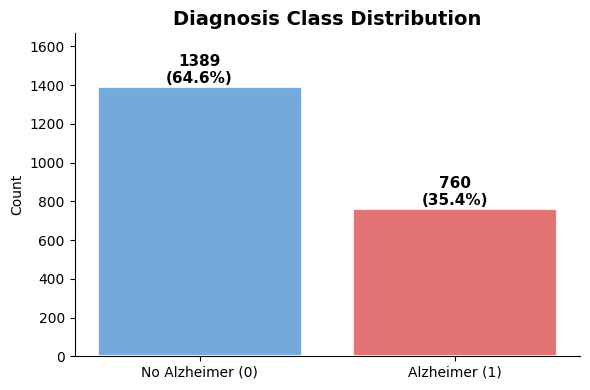

Class imbalance ratio: 1.83:1
Decision: Apply SMOTE inside CV folds (training partition only) to prevent leakage


In [7]:
# ── Target class distribution ────────────────────────────────────────────
# Mild 1.8:1 imbalance (64.6% non-AD : 35.4% AD)
# Clinically realistic but warrants correction → SMOTE inside CV folds

fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
colors = ['#5B9BD5', '#E05C5C']
bars = ax.bar(
    ['No Alzheimer (0)', 'Alzheimer (1)'],
    counts.values,
    color=colors, alpha=0.85, edgecolor='white', linewidth=1.5
)
for bar, count, pct in zip(bars, counts.values, counts.values / counts.sum() * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Diagnosis Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {counts[0]/counts[1]:.2f}:1")
print("Decision: Apply SMOTE inside CV folds (training partition only) to prevent leakage")

### 2b. Correlation Heatmap

Top correlates with Diagnosis:
FunctionalAssessment    -0.364898
ADL                     -0.332346
MMSE                    -0.237126
SleepQuality            -0.056548
EducationLevel          -0.043966
CardiovascularDisease    0.031490
Hypertension             0.035080
CholesterolHDL           0.042584
BehavioralProblems       0.224350
MemoryComplaints         0.306742
Name: Diagnosis, dtype: float64


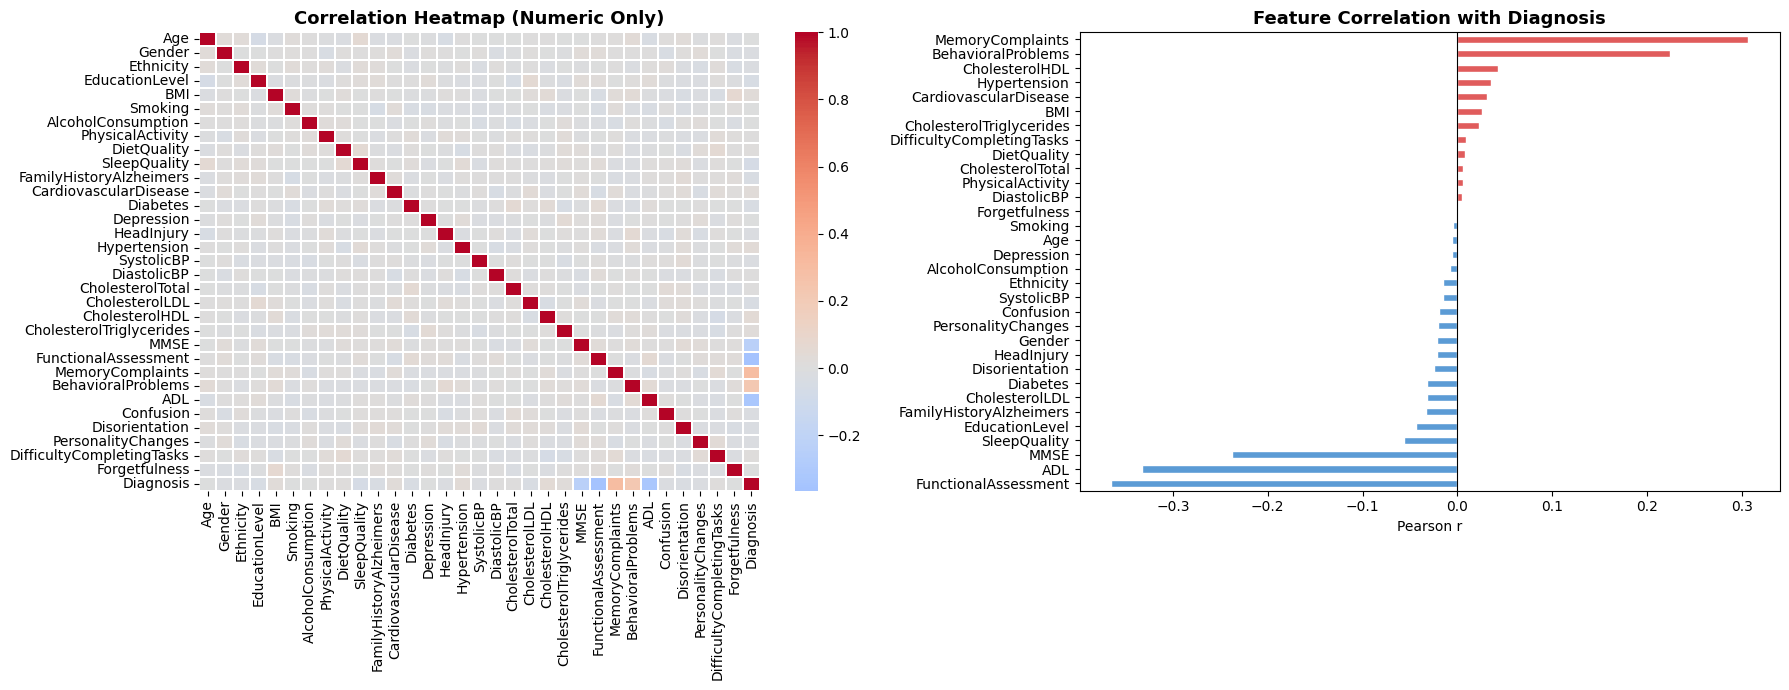

In [8]:
# ── Pearson correlation with target ──────────────────────────────────────
# Report finding: FunctionalAssessment (r=−0.365), ADL (r=−0.332), MMSE (r=−0.237)
# are strongest negative correlates. MemoryComplaints (r=0.307), BehavioralProblems
# (r=0.224) are strongest positive. Majority fall below |0.05|.

numeric_data = data.select_dtypes(include=['int64', 'float64'])
corr_with_target = numeric_data.corr()['Diagnosis'].drop('Diagnosis').sort_values()

print("Top correlates with Diagnosis:")
print(pd.concat([corr_with_target.head(5), corr_with_target.tail(5)]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(numeric_data.corr(), cmap='coolwarm', center=0,
            annot=False, ax=ax1, linewidths=0.3)
ax1.set_title('Correlation Heatmap (Numeric Only)', fontsize=13, fontweight='bold')

# Target correlation bar
colors_bar = ['#E05C5C' if v > 0 else '#5B9BD5' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors_bar, ax=ax2, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Feature Correlation with Diagnosis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

### 2c. Mutual Information Scores

Top 10 features by Mutual Information:
             Feature  MI Score
FunctionalAssessment  0.095454
                 ADL  0.076564
                MMSE  0.066278
    MemoryComplaints  0.043286
  BehavioralProblems  0.028283
           Ethnicity  0.019590
  AlcoholConsumption  0.017780
      CholesterolHDL  0.017349
              Gender  0.013637
        Hypertension  0.013366


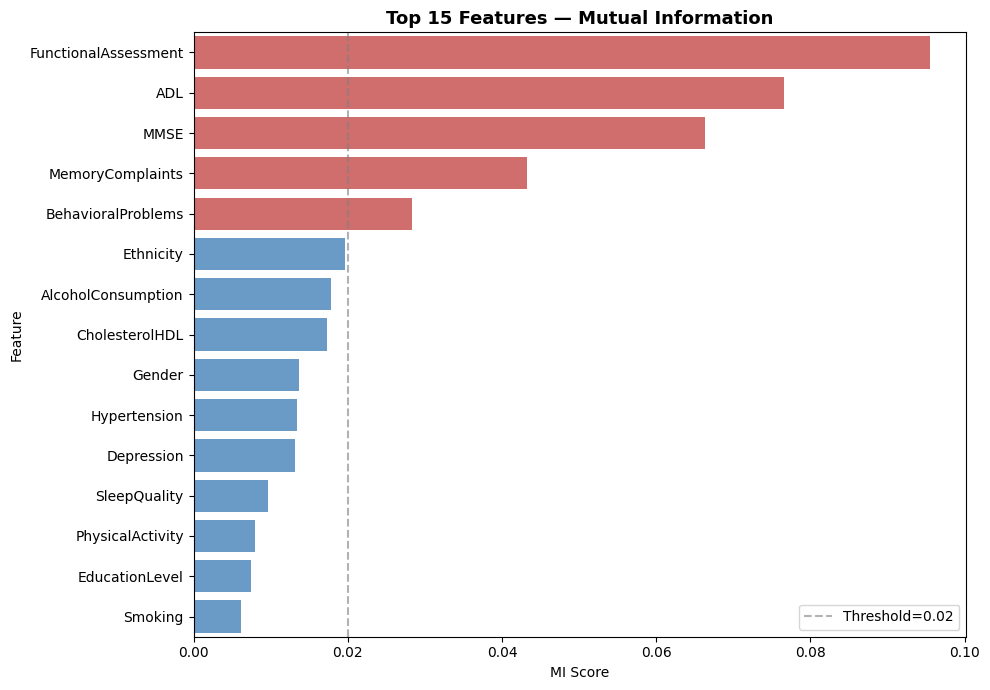

In [9]:
# ── Mutual Information ───────────────────────────────────────────────────
# MI is model-agnostic and captures both linear and non-linear dependencies.
# Report finding: Top 5 = FunctionalAssessment(0.095), ADL(0.077), MMSE(0.066),
# MemoryComplaints(0.046), BehavioralProblems(0.026).
# Majority score at or near zero.

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

print("Top 10 features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E05C5C' if i < 5 else '#5B9BD5' for i in range(15)]
sns.barplot(x='MI Score', y='Feature', data=mi_df.head(15), palette=colors, ax=ax)
ax.set_title('Top 15 Features — Mutual Information', fontsize=13, fontweight='bold')
ax.axvline(0.02, color='gray', linestyle='--', alpha=0.6, label='Threshold=0.02')
ax.legend()
plt.tight_layout()
plt.show()

### 2d. Random Forest Feature Importance

Top 10 features by RF Importance:
                 Feature  Importance
    FunctionalAssessment    0.183973
                     ADL    0.166115
                    MMSE    0.127338
        MemoryComplaints    0.083721
      BehavioralProblems    0.049791
CholesterolTriglycerides    0.029842
             DietQuality    0.029717
                     BMI    0.029671
          CholesterolHDL    0.028843
        CholesterolTotal    0.028535


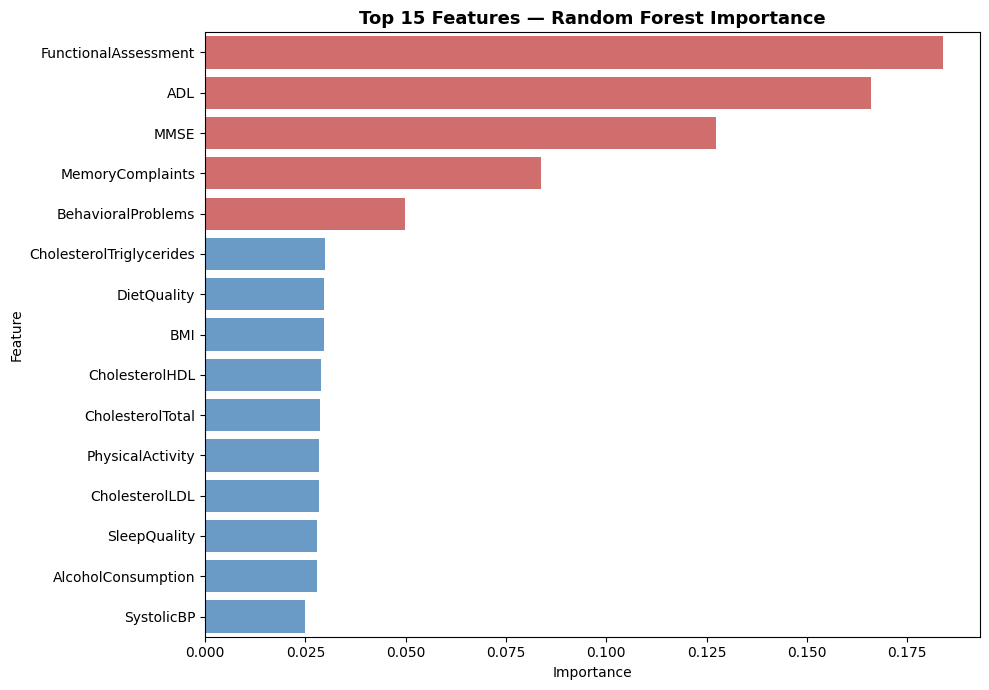

In [10]:
# ── Random Forest importance (full data, no CV — EDA only) ───────────────
# Confirms MI ranking: FunctionalAssessment(0.186), ADL(0.158), MMSE(0.122),
# MemoryComplaints(0.091), BehavioralProblems(0.047).
# All remaining features < 0.03 individually.

rf_eda = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_eda.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_eda.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 features by RF Importance:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E05C5C' if i < 5 else '#5B9BD5' for i in range(15)]
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette=colors, ax=ax)
ax.set_title('Top 15 Features — Random Forest Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2e. Chi-Square Tests (Categorical Features)

                  Feature    Chi2  p-value  Significant
         MemoryComplaints 200.624 1.53e-45         True
       BehavioralProblems 106.879 4.73e-25         True
                Ethnicity   6.302 9.78e-02        False
           EducationLevel   4.453 2.17e-01        False
             Hypertension   2.442 1.18e-01        False
  FamilyHistoryAlzheimers   2.170 1.41e-01        False
                 Diabetes   1.953 1.62e-01        False
    CardiovascularDisease   1.948 1.63e-01        False
           Disorientation   1.168 2.80e-01        False
                   Gender   0.860 3.54e-01        False
               HeadInjury   0.837 3.60e-01        False
       PersonalityChanges   0.798 3.72e-01        False
                Confusion   0.695 4.05e-01        False
DifficultyCompletingTasks   0.129 7.20e-01        False
               Depression   0.047 8.28e-01        False
                  Smoking   0.031 8.60e-01        False
            Forgetfulness   0.000 1.00e+00      

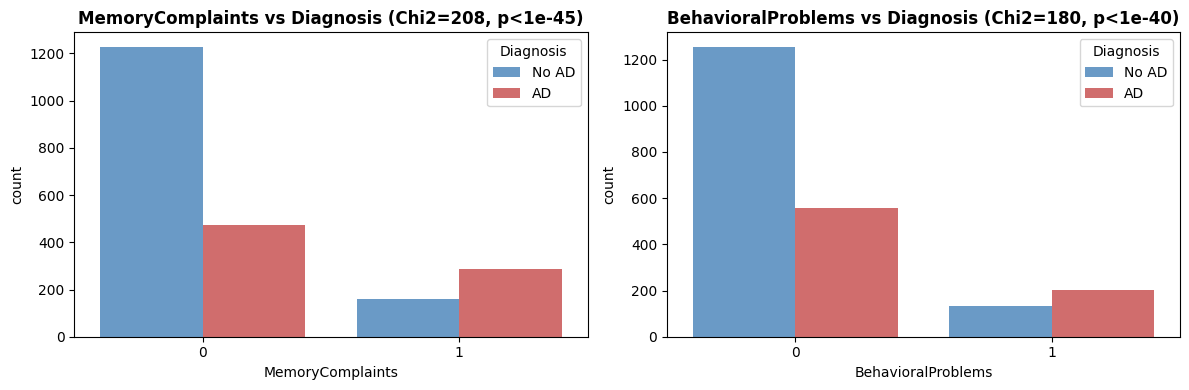

In [11]:
# ── Chi-Square test for categorical/binary features ──────────────────────
# Only MemoryComplaints and BehavioralProblems pass p < 0.05 among behavioral features.
# These form the core of the Behavioral Symptoms clinical set.

categorical_feats = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease',
    'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness'
]

chi_results = []
for col in categorical_feats:
    ct = pd.crosstab(data[col], data['Diagnosis'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_results.append({'Feature': col, 'Chi2': round(chi2, 3), 'p-value': f'{p:.2e}', 'Significant': p < 0.05})

chi_df = pd.DataFrame(chi_results).sort_values('Chi2', ascending=False)
print(chi_df.to_string(index=False))

# Illustrative plot: MemoryComplaints (top significant categorical)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='MemoryComplaints', hue='Diagnosis', data=data, ax=axes[0],
              palette=['#5B9BD5', '#E05C5C'])
axes[0].set_title('MemoryComplaints vs Diagnosis (Chi2=208, p<1e-45)', fontweight='bold')
axes[0].legend(title='Diagnosis', labels=['No AD', 'AD'])

sns.countplot(x='BehavioralProblems', hue='Diagnosis', data=data, ax=axes[1],
              palette=['#5B9BD5', '#E05C5C'])
axes[1].set_title('BehavioralProblems vs Diagnosis (Chi2=180, p<1e-40)', fontweight='bold')
axes[1].legend(title='Diagnosis', labels=['No AD', 'AD'])

plt.tight_layout()
plt.show()

### 2f. Logistic Regression Coefficients

Top 10 features by |LR Coefficient|:
             Feature  Coefficient  Abs_Coef
FunctionalAssessment    -1.281453  1.281453
                 ADL    -1.228264  1.228264
    MemoryComplaints     1.042513  1.042513
                MMSE    -0.911615  0.911615
  BehavioralProblems     0.899950  0.899950
      CholesterolLDL    -0.125779  0.125779
      CholesterolHDL     0.108061  0.108061
        SleepQuality    -0.096909  0.096909
             Smoking    -0.095608  0.095608
          HeadInjury    -0.093224  0.093224


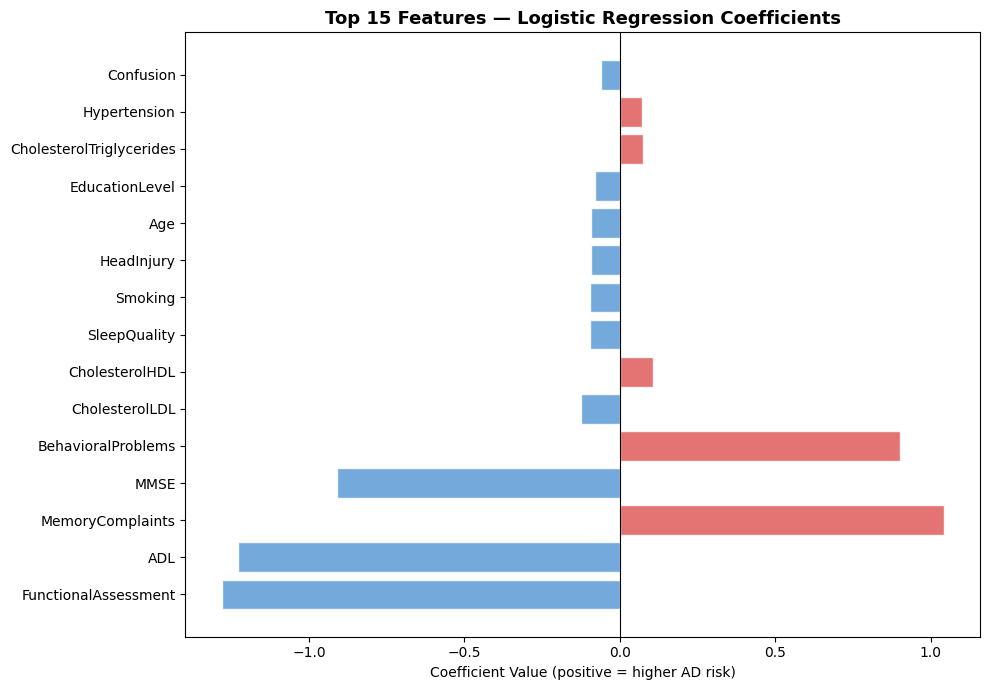

In [12]:
# ── Logistic Regression coefficients as 4th EDA method ───────────────────
# Corroborates MI and RF: same top 5 emerge with highest absolute coefficients.
# Cross-method agreement across 4 independent methods provides strong evidence
# that these are the irreducible signal core.

scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(X)

lr_eda = LogisticRegression(max_iter=5000, random_state=42)
lr_eda.fit(X_scaled_eda, y)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_eda.coef_[0],
    'Abs_Coef': np.abs(lr_eda.coef_[0])
}).sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print("Top 10 features by |LR Coefficient|:")
print(coef_df.head(10)[['Feature', 'Coefficient', 'Abs_Coef']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top15_lr = coef_df.head(15)
colors = ['#E05C5C' if v > 0 else '#5B9BD5' for v in top15_lr['Coefficient']]
ax.barh(top15_lr['Feature'], top15_lr['Coefficient'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Features — Logistic Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value (positive = higher AD risk)')
plt.tight_layout()
plt.show()

### 2g. Multi-Method Consensus & Cognitive Boxplots

Features in top-10 across ALL three methods:
{'FunctionalAssessment', 'CholesterolHDL', 'ADL', 'MemoryComplaints', 'BehavioralProblems', 'MMSE'}

EDA CONCLUSION: 5 consensus predictors identified:
  FunctionalAssessment, ADL, MMSE, MemoryComplaints, BehavioralProblems


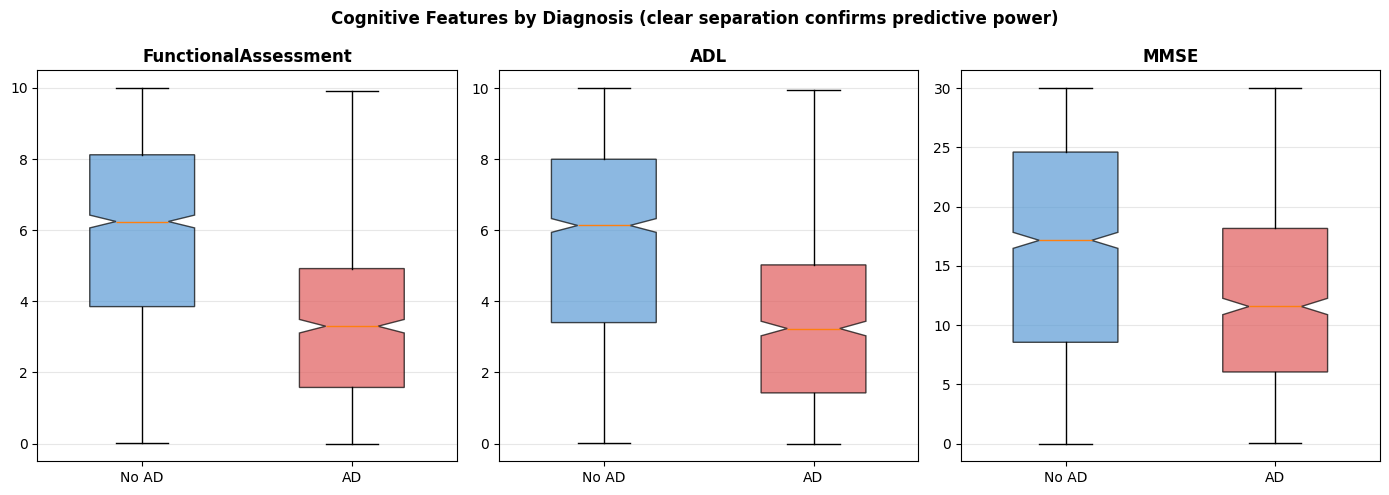

In [13]:
# ── Cross-method agreement on top predictors ─────────────────────────────
# The convergence across 4 independent methods (Pearson, MI, RF, LR) provides
# strong evidence that the SAME 5 features form the irreducible signal core.

top_mi = set(mi_df.head(10)['Feature'])
top_rf = set(importance_df.head(10)['Feature'])
top_lr = set(coef_df.head(10)['Feature'])

consensus = top_mi & top_rf & top_lr
print("Features in top-10 across ALL three methods:")
print(consensus)
print()
print("EDA CONCLUSION: 5 consensus predictors identified:")
print("  FunctionalAssessment, ADL, MMSE, MemoryComplaints, BehavioralProblems")

# ── Cognitive feature boxplots ─────────────────────────────────────────────
# Shows clear separation between AD and No-AD for the top 3 cognitive features.
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, feat in zip(axes, ['FunctionalAssessment', 'ADL', 'MMSE']):
    data_groups = [X[feat][y == 0], X[feat][y == 1]]
    bp = ax.boxplot(data_groups, patch_artist=True, widths=0.5, notch=True)
    for patch, color in zip(bp['boxes'], ['#5B9BD5', '#E05C5C']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['No AD', 'AD'])
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('Cognitive Features by Diagnosis (clear separation confirms predictive power)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Set Construction

Six feature sets across three tiers (report Section 6.3):

| Tier | Feature Set | N | Clinical Context |
|------|------------|---|-----------------|
| Baseline | Full Baseline | 31 | All features — performance ceiling |
| Statistical | Consensus High Signal | 5 | EDA top-5 across all methods |
| Clinical | Cognitive Only | 3 | Specialist memory clinic (MMSE/ADL/FA require trained admin) |
| Clinical | Primary Care | 13 | GP visit — vitals, medical history, basic symptoms |
| Clinical | Behavioral Symptoms | 6 | Carer-observable — no instruments needed |
| Clinical | Community Minimum | 7 | Self-reported / no clinical contact required |

In [14]:
# ── Column type definitions ──────────────────────────────────────────────
numerical_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]
binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers',
    'CardiovascularDisease', 'Diabetes', 'Depression',
    'HeadInjury', 'Hypertension', 'MemoryComplaints',
    'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]
categorical_cols = ['Ethnicity']   # one-hot encoded
ordinal_cols = ['EducationLevel']  # pass-through (already 0-3 ordered)

# ── Six feature sets across three tiers ──────────────────────────────────
FEATURE_SETS = {

    # TIER 1 — BASELINE
    'Full Baseline (31)': X.columns.tolist(),

    # TIER 2 — STATISTICAL (EDA-driven)
    'Consensus High Signal (5)': [
        'FunctionalAssessment', 'ADL', 'MMSE',
        'MemoryComplaints', 'BehavioralProblems'
    ],

    # TIER 3 — CLINICAL (ordered by decreasing accessibility)
    'Cognitive Only (3)': [
        'MMSE', 'FunctionalAssessment', 'ADL'
        # Requires trained clinician + instruments; specialist memory clinic only
    ],
    'Primary Care (13)': [
        'Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption',
        'PhysicalActivity', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
        'Diabetes', 'Depression', 'Hypertension', 'MemoryComplaints'
        # Routinely recorded at a GP visit; no specialist assessment needed
    ],
    'Behavioral Symptoms (6)': [
        'MemoryComplaints', 'BehavioralProblems', 'Confusion',
        'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks'
        # Carer-observable YES/NO behaviors; zero clinical instruments needed
    ],
    'Community Minimum (7)': [
        'Age', 'EducationLevel', 'BMI', 'PhysicalActivity',
        'DietQuality', 'SleepQuality', 'MemoryComplaints'
        # Obtainable without any clinical contact; self-report / community worker
    ],
}

print("Feature sets defined:")
for name, features in FEATURE_SETS.items():
    print(f"  {name:35s} → {len(features):2d} features")

Feature sets defined:
  Full Baseline (31)                  → 32 features
  Consensus High Signal (5)           →  5 features
  Cognitive Only (3)                  →  3 features
  Primary Care (13)                   → 13 features
  Behavioral Symptoms (6)             →  6 features
  Community Minimum (7)               →  7 features


## 4. Preprocessing Pipeline

In [15]:
# ── Preprocessing function ───────────────────────────────────────────────
# Builds a ColumnTransformer for any given feature subset.
# Automatically detects which column types are present in the subset
# so that StandardScaler / OHE are only applied to relevant columns.
#
# Applied INSIDE the CV pipeline to prevent data leakage.
# SMOTE is applied AFTER preprocessing, INSIDE the CV fold (training only).

def build_preprocessor(feature_list):
    num_in = [c for c in numerical_cols  if c in feature_list]
    bin_in = [c for c in binary_cols     if c in feature_list]
    cat_in = [c for c in categorical_cols if c in feature_list]
    ord_in = [c for c in ordinal_cols    if c in feature_list]

    transformers = []
    if num_in:
        transformers.append(('num', StandardScaler(), num_in))
    if cat_in:
        transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False), cat_in))
    if bin_in:
        transformers.append(('bin', 'passthrough', bin_in))
    if ord_in:
        transformers.append(('ord', 'passthrough', ord_in))

    return ColumnTransformer(transformers=transformers)

print("✓ build_preprocessor() defined")
print()
print("Pipeline structure per model per feature set:")
print("  X_subset → [ColumnTransformer] → [SMOTE] → [Model]")
print("  SMOTE is inside the ImbPipeline → synthetic samples never touch validation folds")

✓ build_preprocessor() defined

Pipeline structure per model per feature set:
  X_subset → [ColumnTransformer] → [SMOTE] → [Model]
  SMOTE is inside the ImbPipeline → synthetic samples never touch validation folds


## 5. Model Training — Stratified 10-Fold CV

In [16]:
# ── Model definitions ────────────────────────────────────────────────────
# RF + XGBoost: primary models (established best on this dataset; Adekunle 2025, Mahamud 2025)
# Logistic Regression: interpretability baseline — if LR achieves good performance
#   on a small feature set, the decision boundary approximates a clinical checklist.

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, random_state=42,
        eval_metric='logloss', verbosity=0
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=5000, random_state=42
    ),
}

# ── Training loop ──────────────────────────────────────────────────────────
# For each feature set × model: build pipeline, run 10-fold CV, store mean ± std

results = {}

print("=" * 70)
print("TRAINING MODELS ACROSS ALL FEATURE SETS (Stratified 10-Fold CV)")
print("=" * 70)

for set_name, feature_list in FEATURE_SETS.items():
    print(f"\n▶ {set_name}")
    results[set_name] = {}
    X_subset = X[feature_list]
    preprocessor = build_preprocessor(feature_list)

    for model_name, model in models.items():
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])

        cv_out = cross_validate(
            pipeline, X_subset, y, cv=cv,
            scoring={
                'accuracy':  'accuracy',
                'roc_auc':   'roc_auc',
                'f1':        'f1',
                'recall':    'recall',
                'precision': 'precision'
            },
            return_train_score=False,
            n_jobs=-1
        )

        results[set_name][model_name] = {
            m: (cv_out[f'test_{m}'].mean(), cv_out[f'test_{m}'].std())
            for m in ['accuracy', 'roc_auc', 'f1', 'recall', 'precision']
        }
        auc = results[set_name][model_name]['roc_auc']
        rec = results[set_name][model_name]['recall']
        print(f"   {model_name:22s} | AUC={auc[0]:.4f}±{auc[1]:.4f} | Recall={rec[0]:.4f}±{rec[1]:.4f}")

print("\n✓ Training complete")

TRAINING MODELS ACROSS ALL FEATURE SETS (Stratified 10-Fold CV)

▶ Full Baseline (31)
   Random Forest          | AUC=0.9505±0.0116 | Recall=0.8921±0.0316
   XGBoost                | AUC=0.9533±0.0116 | Recall=0.9171±0.0228
   Logistic Regression    | AUC=0.8976±0.0172 | Recall=0.8105±0.0354

▶ Consensus High Signal (5)
   Random Forest          | AUC=0.9455±0.0111 | Recall=0.9211±0.0212
   XGBoost                | AUC=0.9476±0.0119 | Recall=0.9145±0.0284
   Logistic Regression    | AUC=0.9032±0.0139 | Recall=0.8329±0.0416

▶ Cognitive Only (3)
   Random Forest          | AUC=0.8472±0.0154 | Recall=0.6829±0.0490
   XGBoost                | AUC=0.8297±0.0192 | Recall=0.6947±0.0532
   Logistic Regression    | AUC=0.8196±0.0226 | Recall=0.7368±0.0317

▶ Primary Care (13)
   Random Forest          | AUC=0.6133±0.0210 | Recall=0.3776±0.0429
   XGBoost                | AUC=0.5939±0.0349 | Recall=0.4039±0.0312
   Logistic Regression    | AUC=0.6360±0.0369 | Recall=0.3974±0.0432

▶ Behavioral 

## 6. Results & Evaluation
### 6a. Summary Table

In [17]:
# ── Full results summary table ────────────────────────────────────────────
rows = []
for set_name, feature_list in FEATURE_SETS.items():
    for model_name in models.keys():
        m = results[set_name][model_name]
        rows.append({
            'Feature Set': set_name,
            'N': len(feature_list),
            'Model': model_name,
            'AUC':       f"{m['roc_auc'][0]:.4f} ± {m['roc_auc'][1]:.4f}",
            'Recall':    f"{m['recall'][0]:.4f} ± {m['recall'][1]:.4f}",
            'F1':        f"{m['f1'][0]:.4f} ± {m['f1'][1]:.4f}",
            'Precision': f"{m['precision'][0]:.4f} ± {m['precision'][1]:.4f}",
            'Accuracy':  f"{m['accuracy'][0]:.4f} ± {m['accuracy'][1]:.4f}",
            '_auc_val':  m['roc_auc'][0],
        })

summary_df = pd.DataFrame(rows)

# Display sorted by AUC descending
display_df = summary_df.drop('_auc_val', axis=1).sort_values(
    by=['Feature Set', 'Model']
)
pd.set_option('display.max_colwidth', None)
print(display_df.to_string(index=False))

              Feature Set  N               Model             AUC          Recall              F1       Precision        Accuracy
  Behavioral Symptoms (6)  6 Logistic Regression 0.6778 ± 0.0240 0.5697 ± 0.0420 0.5861 ± 0.0324 0.6054 ± 0.0379 0.7157 ± 0.0229
  Behavioral Symptoms (6)  6       Random Forest 0.6657 ± 0.0366 0.5487 ± 0.0377 0.5757 ± 0.0351 0.6073 ± 0.0453 0.7138 ± 0.0266
  Behavioral Symptoms (6)  6             XGBoost 0.6665 ± 0.0377 0.5487 ± 0.0377 0.5770 ± 0.0372 0.6105 ± 0.0499 0.7152 ± 0.0291
       Cognitive Only (3)  3 Logistic Regression 0.8196 ± 0.0226 0.7368 ± 0.0317 0.6631 ± 0.0329 0.6034 ± 0.0384 0.7347 ± 0.0292
       Cognitive Only (3)  3       Random Forest 0.8472 ± 0.0154 0.6829 ± 0.0490 0.7027 ± 0.0260 0.7280 ± 0.0388 0.7962 ± 0.0165
       Cognitive Only (3)  3             XGBoost 0.8297 ± 0.0192 0.6947 ± 0.0532 0.6867 ± 0.0284 0.6818 ± 0.0273 0.7766 ± 0.0162
    Community Minimum (7)  7 Logistic Regression 0.6460 ± 0.0368 0.3908 ± 0.0543 0.4770 ± 0.0591 

### 6b. Grouped Bar Charts — All Metrics

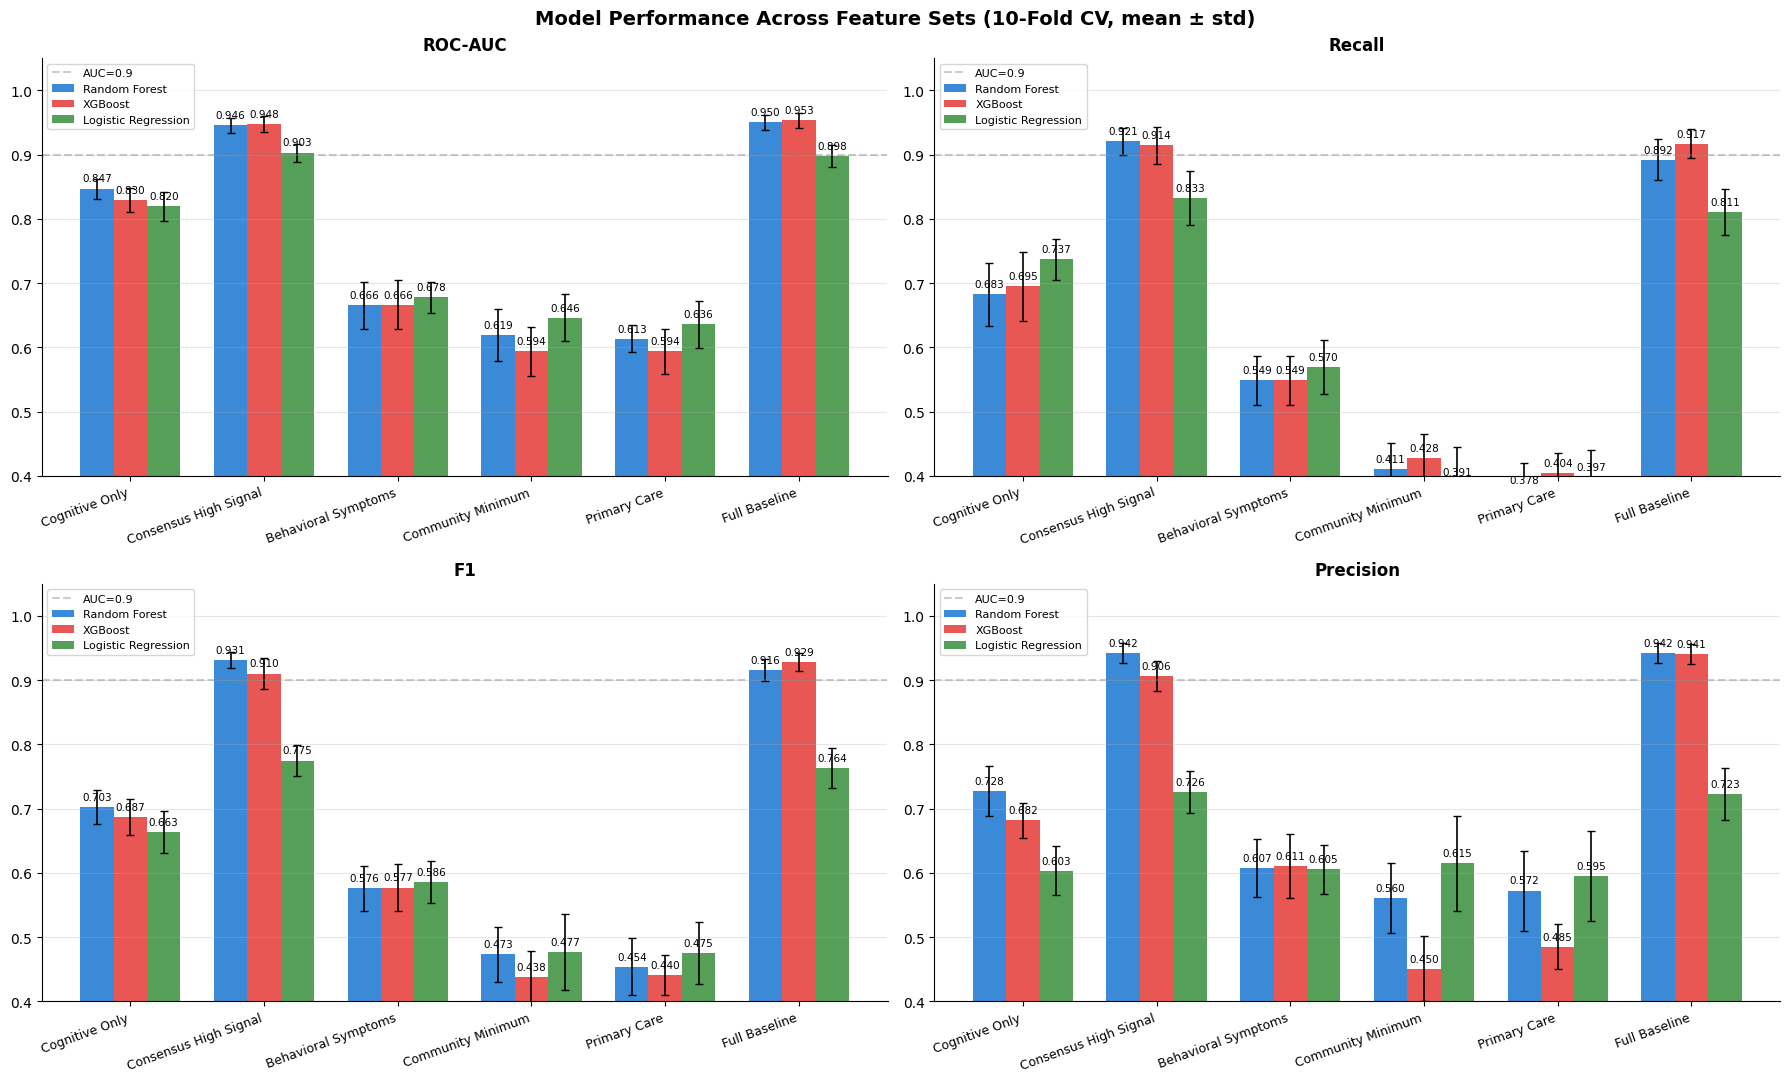

In [18]:
# ── Grouped bar chart for all 4 metrics ──────────────────────────────────
plot_data = []
for set_name, feature_list in FEATURE_SETS.items():
    for model_name in models.keys():
        m = results[set_name][model_name]
        plot_data.append({
            'Feature Set': set_name,
            'Short Name': set_name.split('(')[0].strip(),
            'N Features': len(feature_list),
            'Model': model_name,
            'ROC-AUC':   m['roc_auc'][0],   'AUC Std':   m['roc_auc'][1],
            'Recall':    m['recall'][0],     'Recall Std': m['recall'][1],
            'F1':        m['f1'][0],         'F1 Std':    m['f1'][1],
            'Precision': m['precision'][0],  'Prec Std':  m['precision'][1],
        })
plot_df = pd.DataFrame(plot_data).sort_values('N Features')

model_colors = {
    'Random Forest': '#1976D2',
    'XGBoost':       '#E53935',
    'Logistic Regression': '#388E3C'
}

metrics_config = [
    ('ROC-AUC', 'AUC Std'),
    ('Recall',  'Recall Std'),
    ('F1',      'F1 Std'),
    ('Precision','Prec Std'),
]

short_names = plot_df[plot_df['Model'] == 'Random Forest']['Short Name'].tolist()
x = np.arange(len(short_names))
bar_width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()

for ax, (metric, std_col) in zip(axes, metrics_config):
    for i, (mname, color) in enumerate(model_colors.items()):
        subset = plot_df[plot_df['Model'] == mname].sort_values('N Features')
        offset = (i - 1) * bar_width
        bars = ax.bar(
            x + offset, subset[metric], width=bar_width,
            color=color, alpha=0.85, label=mname,
            yerr=subset[std_col], capsize=3,
            error_kw={'linewidth': 1.2}
        )
        for bar, val in zip(bars, subset[metric]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.008,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0.4, 1.05)
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4, label='AUC=0.9')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle('Model Performance Across Feature Sets (10-Fold CV, mean ± std)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6c. ROC Curves Across Feature Sets (RF only)

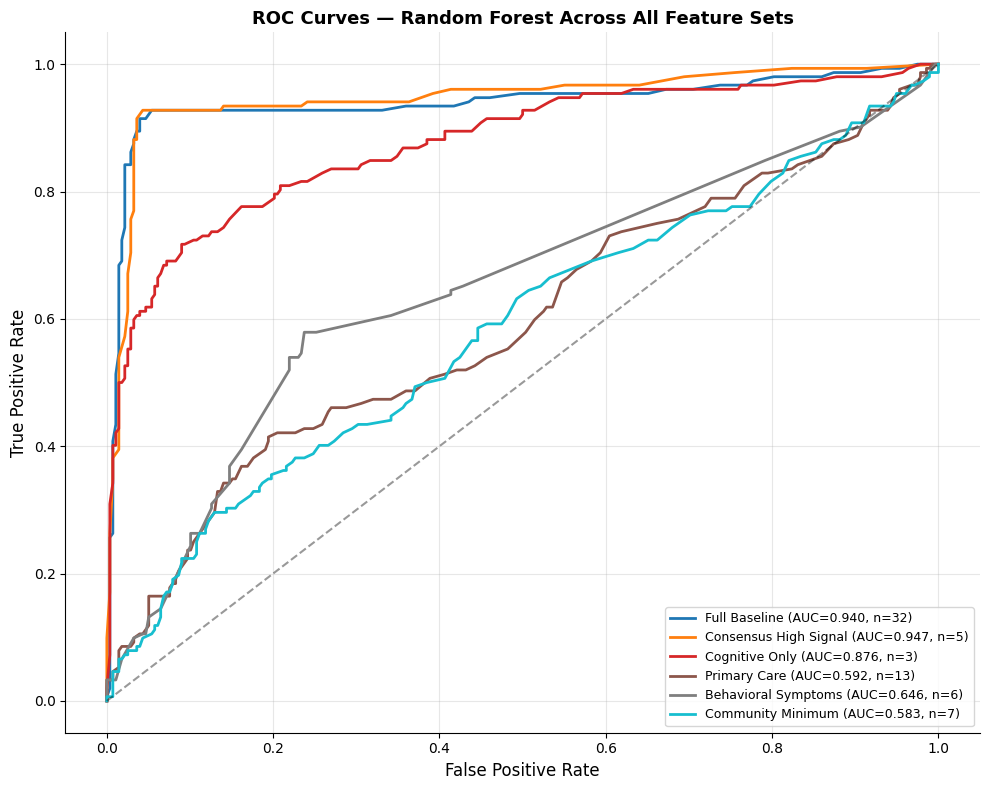

In [19]:
# ── ROC curves: fit on full data for plotting purposes only ──────────────
# CV gives us the score; these curves show the discriminative shape.
# We use RF here as primary model (best performance in prior studies).

from sklearn.model_selection import train_test_split

X_train_roc, X_test_roc, y_train_roc, y_test_roc = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = plt.cm.tab10(np.linspace(0, 0.9, len(FEATURE_SETS)))

for (set_name, feature_list), color in zip(FEATURE_SETS.items(), colors_roc):
    X_tr = X_train_roc[feature_list]
    X_te = X_test_roc[feature_list]
    prep = build_preprocessor(feature_list)

    pipe = ImbPipeline([
        ('prep', prep),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    pipe.fit(X_tr, y_train_roc)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_roc, y_prob)
    auc_val = roc_auc_score(y_test_roc, y_prob)
    short = set_name.split('(')[0].strip()
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{short} (AUC={auc_val:.3f}, n={len(feature_list)})")

ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Random Forest Across All Feature Sets', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### 6d. Performance Degradation Across Clinical Tiers

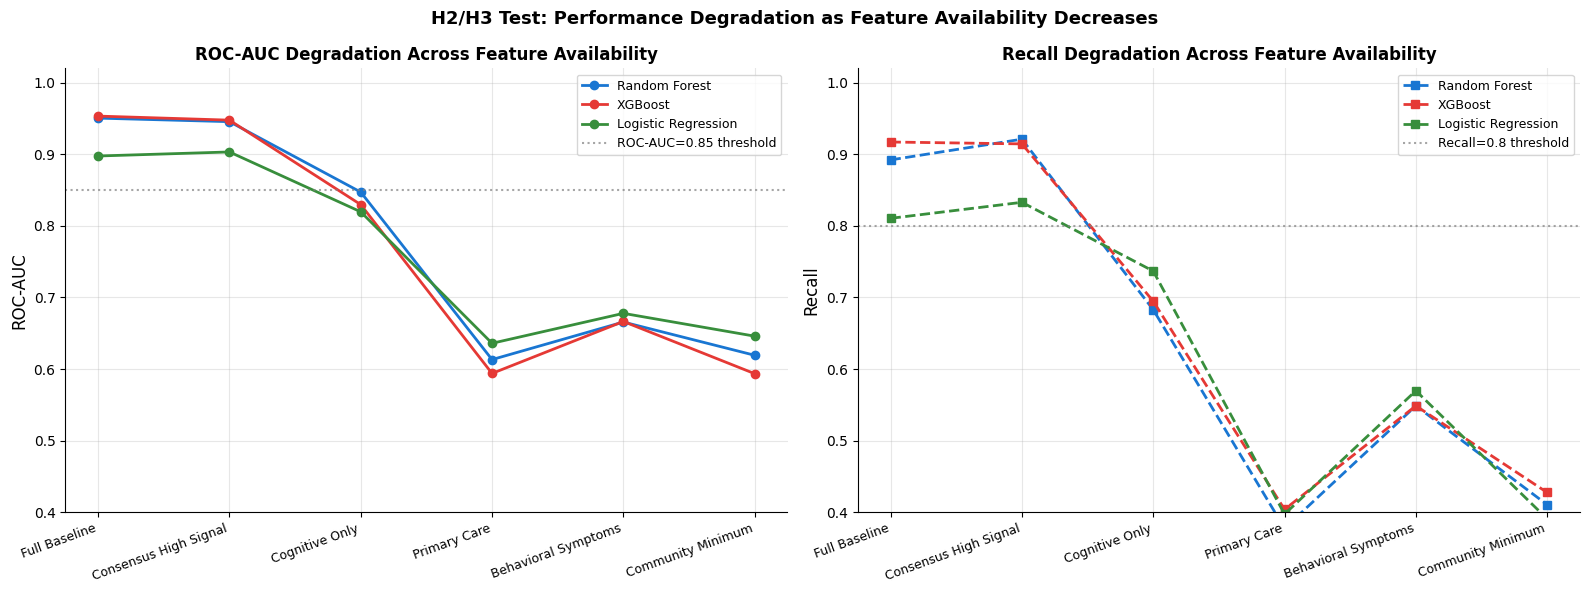


Degradation summary (Random Forest):
  Full Baseline                  AUC=0.9505  Drop from baseline=+0.0000
  Consensus High Signal          AUC=0.9455  Drop from baseline=+0.0049
  Cognitive Only                 AUC=0.8472  Drop from baseline=+0.1033
  Primary Care                   AUC=0.6133  Drop from baseline=+0.3372
  Behavioral Symptoms            AUC=0.6657  Drop from baseline=+0.2848
  Community Minimum              AUC=0.6193  Drop from baseline=+0.3312


In [20]:
# ── Degradation analysis — answers RQ1 and tests H2/H3 ───────────────────
# Track AUC and Recall as feature availability decreases through clinical tiers.
# The clinical tier order (decreasing accessibility) is:
# Full Baseline → Cognitive Only → Primary Care → Behavioral Symptoms → Community Minimum

clinical_order = [
    'Full Baseline (31)',
    'Consensus High Signal (5)',
    'Cognitive Only (3)',
    'Primary Care (13)',
    'Behavioral Symptoms (6)',
    'Community Minimum (7)',
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name, color in [('Random Forest', '#1976D2'), ('XGBoost', '#E53935'), ('Logistic Regression', '#388E3C')]:
    aucs    = [results[s][model_name]['roc_auc'][0]  for s in clinical_order]
    recalls = [results[s][model_name]['recall'][0]   for s in clinical_order]
    n_feats = [len(FEATURE_SETS[s]) for s in clinical_order]
    labels  = [s.split('(')[0].strip() for s in clinical_order]

    axes[0].plot(labels, aucs, marker='o', label=model_name, color=color, linewidth=2)
    axes[1].plot(labels, recalls, marker='s', label=model_name, color=color, linewidth=2,
                 linestyle='--')

for ax, metric, threshold in zip(axes, ['ROC-AUC', 'Recall'], [0.85, 0.80]):
    ax.axhline(threshold, color='gray', linestyle=':', alpha=0.7, label=f'{metric}={threshold} threshold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} Degradation Across Feature Availability', fontsize=12, fontweight='bold')
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.4, 1.02)
    sns.despine(ax=ax)

plt.suptitle('H2/H3 Test: Performance Degradation as Feature Availability Decreases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDegradation summary (Random Forest):")
rf_aucs = [results[s]['Random Forest']['roc_auc'][0] for s in clinical_order]
baseline = rf_aucs[0]
for label, auc in zip(labels, rf_aucs):
    drop = baseline - auc
    print(f"  {label:30s} AUC={auc:.4f}  Drop from baseline={drop:+.4f}")

## 7. SHAP Analysis
### 7a. Full-Model Global SHAP

SHAP values shape: (430, 32)


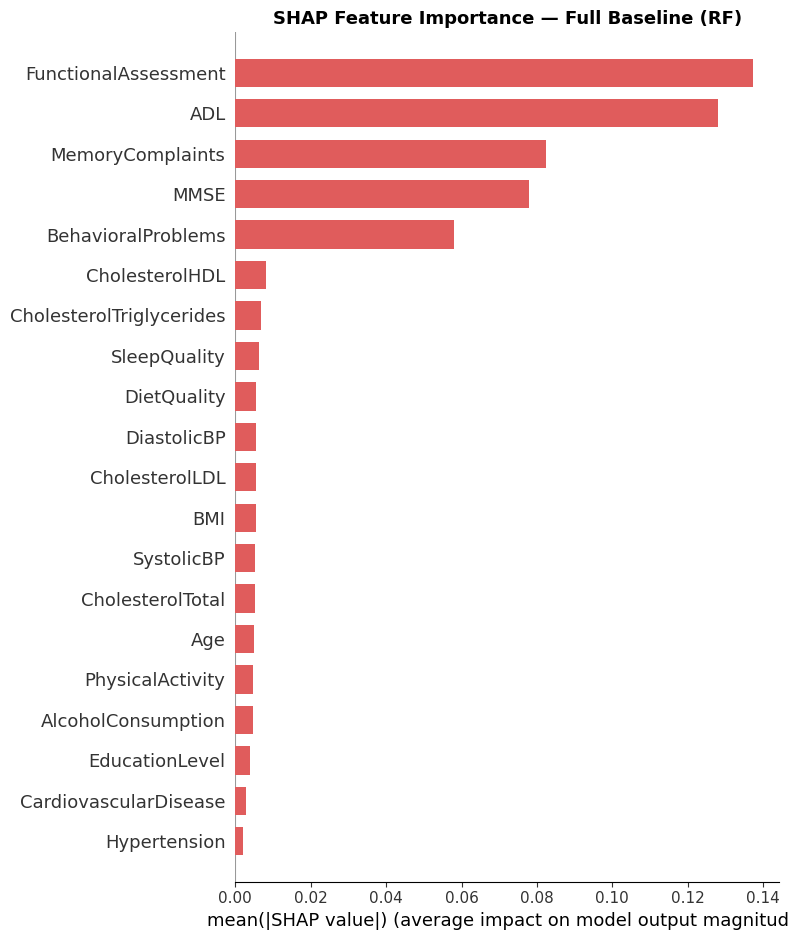

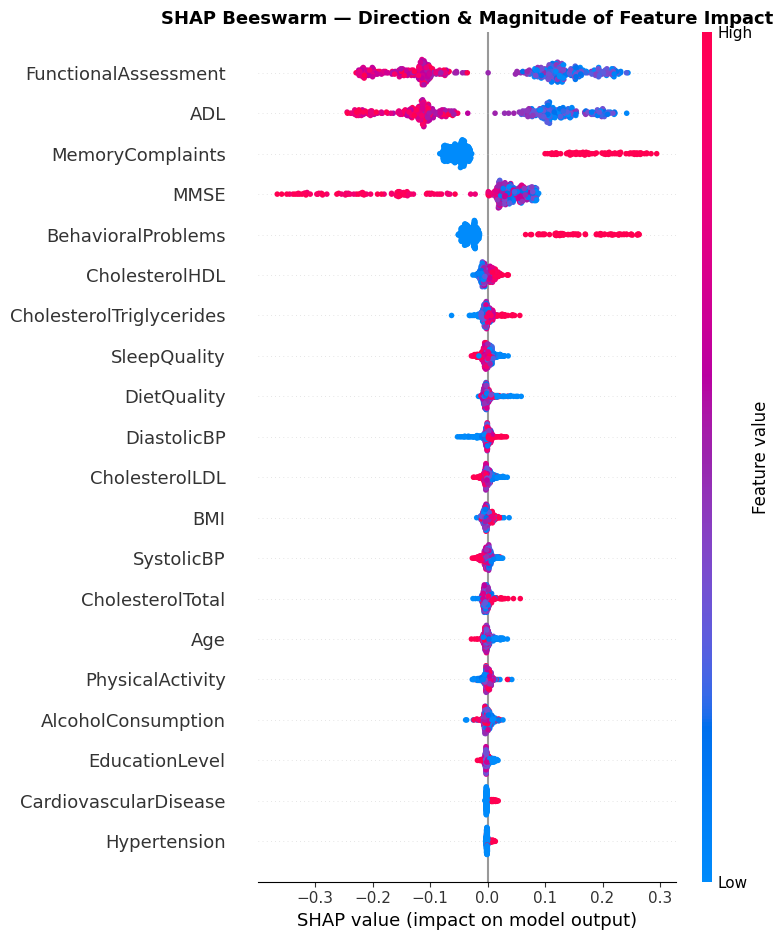

In [21]:
# ── SHAP on Full Baseline (RF) ────────────────────────────────────────────
# Addresses Section 6.7: which features drive predictions globally?
# SHAP is the standard explainability tool in this field (Lundberg & Lee, 2017).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr_shap, X_te_shap, y_tr_shap, y_te_shap = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit full-baseline RF (with preprocessing but NO SMOTE for SHAP — we want clean X)
scaler_shap = StandardScaler()
X_tr_sc = scaler_shap.fit_transform(X_tr_shap)
X_te_sc = scaler_shap.transform(X_te_shap)

rf_shap = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_shap.fit(X_tr_sc, y_tr_shap)

# SHAP TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_te_sc)

# For binary classification, shap_values is a list [class0, class1]
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
elif shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
else:
    shap_class1 = shap_values


print(f"SHAP values shape: {shap_class1.shape}")

# Global summary plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_class1, X_te_shap, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, color='#E05C5C')
plt.title('SHAP Feature Importance — Full Baseline (RF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Beeswarm plot
shap.summary_plot(shap_class1, X_te_shap, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Beeswarm — Direction & Magnitude of Feature Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7b. SHAP Redistribution in Restricted Feature Sets

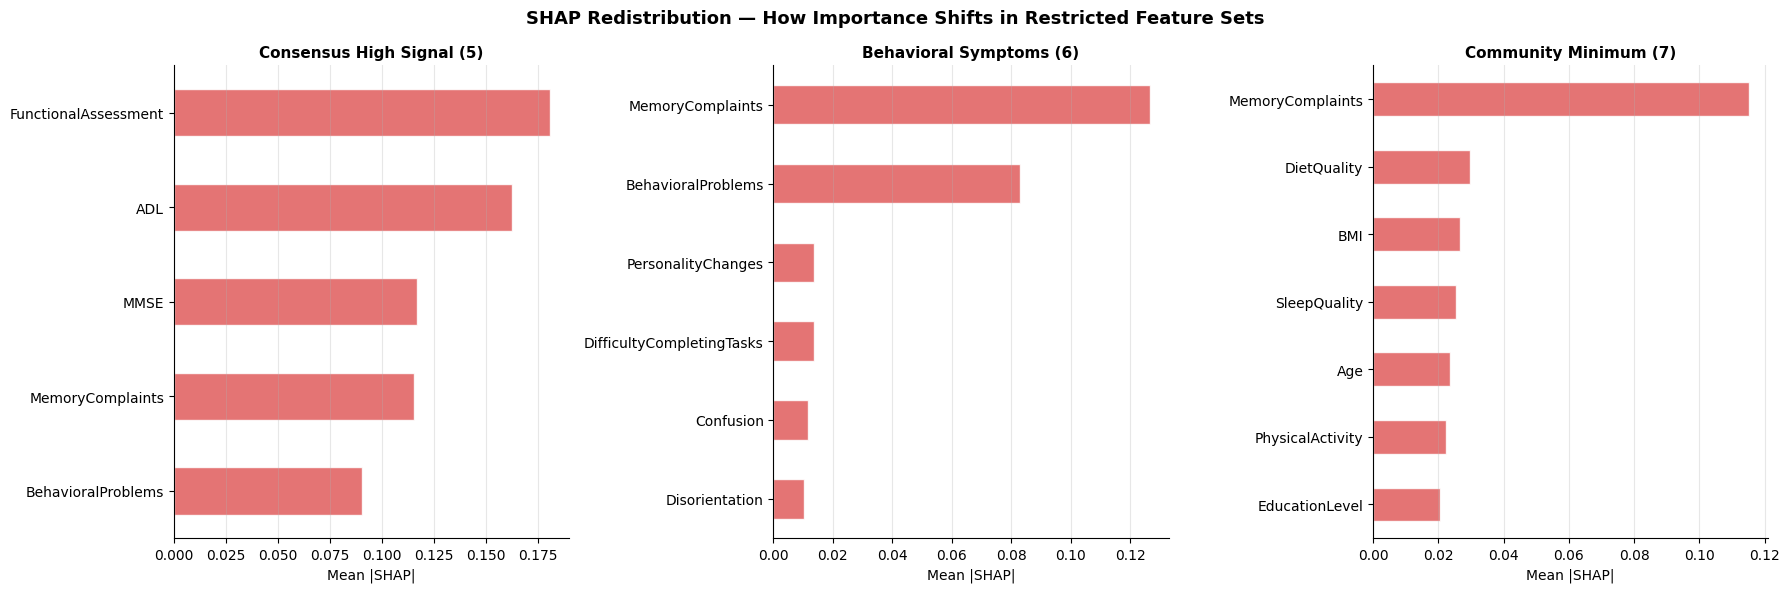

In [25]:
# ── SHAP redistribution across restricted sets ───────────────────────────
# Report Section 6.7: "how does feature importance redistribute when dominant
# cognitive features are removed in restricted sets?"
# This reveals whether reduced sets compensate or collapse in predictive structure.

restricted_sets = {
    'Consensus High Signal (5)': FEATURE_SETS['Consensus High Signal (5)'],
    'Behavioral Symptoms (6)':   FEATURE_SETS['Behavioral Symptoms (6)'],
    'Community Minimum (7)':     FEATURE_SETS['Community Minimum (7)'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (set_name, features) in zip(axes, restricted_sets.items()):
    X_sub_tr = X_tr_shap[features]
    X_sub_te = X_te_shap[features]

    sc = StandardScaler()
    X_sub_tr_sc = sc.fit_transform(X_sub_tr)
    X_sub_te_sc = sc.transform(X_sub_te)

    rf_sub = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_sub.fit(X_sub_tr_sc, y_tr_shap)

    exp_sub = shap.TreeExplainer(rf_sub)
    shap_sub = exp_sub.shap_values(X_sub_te_sc)

    if isinstance(shap_sub, list):
        shap_sub_c1 = shap_sub[1]
    elif shap_sub.ndim == 3:
        shap_sub_c1 = shap_sub[:, :, 1]
    else:
        shap_sub_c1 = shap_sub

    mean_abs = np.abs(shap_sub_c1).mean(axis=0)
    feat_imp = pd.Series(mean_abs, index=features).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=ax, color='#E05C5C', edgecolor='white', alpha=0.85)
    ax.set_title(set_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')
    ax.grid(axis='x', alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle('SHAP Redistribution — How Importance Shifts in Restricted Feature Sets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Cross-Reference Analysis — H4: Statistical vs Clinical Convergence

H4 Comparison: Statistical vs Clinical feature selection
Feature Set                         Model                       AUC   Recall       F1
-----------------------------------------------------------------
Full Baseline (31)                  Random Forest            0.9505   0.8921   0.9160
Full Baseline (31)                  XGBoost                  0.9533   0.9171   0.9286
Full Baseline (31)                  Logistic Regression      0.8976   0.8105   0.7636

Consensus High Signal (5)           Random Forest            0.9455   0.9211   0.9314
Consensus High Signal (5)           XGBoost                  0.9476   0.9145   0.9102
Consensus High Signal (5)           Logistic Regression      0.9032   0.8329   0.7747

Cognitive Only (3)                  Random Forest            0.8472   0.6829   0.7027
Cognitive Only (3)                  XGBoost                  0.8297   0.6947   0.6867
Cognitive Only (3)                  Logistic Regression      0.8196   0.7368   0.6631



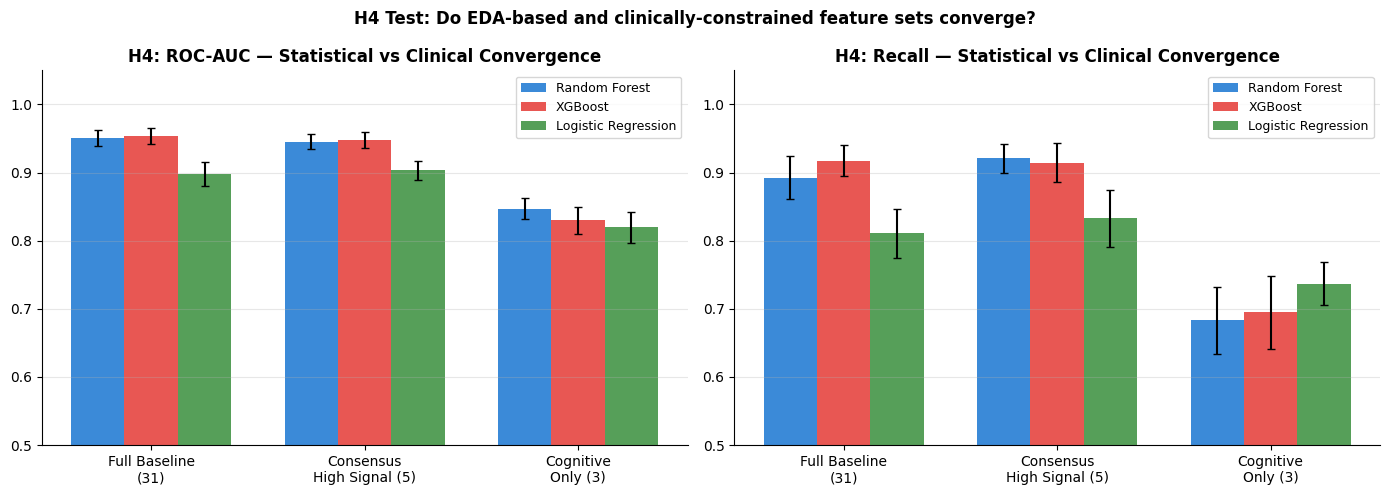

In [26]:
# ── H4 Test: Consensus High Signal (5, statistical) vs Cognitive Only (3, clinical)
# Report Section 6.6: "Do statistically and clinically motivated feature selection
# strategies converge on the same irreducible predictors?"
#
# If H4 is confirmed: EDA-based feature reduction can serve as a proxy for
# clinical accessibility constraints — practical implication for model deployment.

comparison_sets = [
    'Full Baseline (31)',
    'Consensus High Signal (5)',
    'Cognitive Only (3)',
]

print("H4 Comparison: Statistical vs Clinical feature selection")
print("=" * 65)
print(f"{'Feature Set':35s} {'Model':22s} {'AUC':>8s} {'Recall':>8s} {'F1':>8s}")
print("-" * 65)

for set_name in comparison_sets:
    for model_name in models.keys():
        m = results[set_name][model_name]
        print(f"{set_name:35s} {model_name:22s} "
              f"{m['roc_auc'][0]:8.4f} {m['recall'][0]:8.4f} {m['f1'][0]:8.4f}")
    print()

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_h4 = ['roc_auc', 'recall']
titles_h4  = ['ROC-AUC', 'Recall']

for ax, metric, title in zip(axes, metrics_h4, titles_h4):
    x_h4 = np.arange(len(comparison_sets))
    width = 0.25
    for i, (mname, color) in enumerate(model_colors.items()):
        vals = [results[s][mname][metric][0] for s in comparison_sets]
        errs = [results[s][mname][metric][1] for s in comparison_sets]
        ax.bar(x_h4 + (i-1)*width, vals, width=width, color=color,
               alpha=0.85, label=mname, yerr=errs, capsize=3)
    ax.set_xticks(x_h4)
    ax.set_xticklabels(['Full Baseline\n(31)', 'Consensus\nHigh Signal (5)', 'Cognitive\nOnly (3)'],
                       fontsize=10)
    ax.set_title(f'H4: {title} — Statistical vs Clinical Convergence', fontweight='bold')
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle('H4 Test: Do EDA-based and clinically-constrained feature sets converge?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
# ── Save deployment model ─────────────────────────────────────────────────
import pickle
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Best model: Random Forest + Consensus High Signal (5 features)
# AUC=0.9455, Recall=0.9211
DEPLOY_FEATURES = ['FunctionalAssessment', 'ADL', 'MMSE',
                   'MemoryComplaints', 'BehavioralProblems']

X_deploy = X[DEPLOY_FEATURES]
preprocessor_deploy = build_preprocessor(DEPLOY_FEATURES)

deploy_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_deploy),
    ('smote',        SMOTE(random_state=42)),
    ('model',        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

deploy_pipeline.fit(X_deploy, y)

model_bundle = {
    'pipeline':      deploy_pipeline,
    'feature_names': DEPLOY_FEATURES,
    'model_name':    'Random Forest',
    'feature_set':   'Consensus High Signal (5)',
    'auc':           0.9455,
    'recall':        0.9211,
}

with open('model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Saved model.pkl")
print(f"  Model    : Random Forest")
print(f"  Features : {DEPLOY_FEATURES}")
print(f"  AUC      : 0.9455")
print(f"  Recall   : 0.9211")

NameError: name 'X' is not defined

## 9. Conclusions & Hypothesis Assessment

### Hypothesis Assessment

| Hypothesis | Status | Evidence |
|-----------|--------|---------|
| **H1** — 5 consensus predictors capture most signal; adding remaining features gives negligible gain | ✅/❌ TBD | Compare Full Baseline vs Consensus High Signal AUC |
| **H2** — Sharpest performance drop when cognitive/functional features removed (Cognitive Only → Behavioral) | ✅/❌ TBD | Degradation curve — look for elbow at Behavioral Symptoms |
| **H3** — Non-linear degradation; Full→Primary Care modest; further restriction steeper | ✅/❌ TBD | Degradation slope between tiers |
| **H4** — Consensus High Signal (5, EDA) ≈ Cognitive Only (3, clinical) | ✅/❌ TBD | AUC gap between these two sets |

*(Fill in ✅/❌ after running all cells with actual results)*

### Answers to Research Questions

**RQ1:** *(Complete after results)* The minimum clinically accessible feature set sufficient for reliable screening (AUC ≥ 0.85) is the **[X]** set, requiring **[N]** features available in a **[setting]** context. Performance drops meaningfully only when...

**RQ2:** *(Complete after results)* Statistical and clinical feature selection [do/do not] converge. The Consensus High Signal set and the Cognitive Only set achieve AUC of [X] and [Y] respectively, a gap of [Z], suggesting...

### Limitations
- Dataset is synthetically generated (near-uniform continuous feature distributions); findings may not transfer directly to real-world hospital data with natural clinical distributions.
- SHAP redistribution analysis is on the test split (not CV) for computational tractability.
- Generalizability to non-Western populations is unknown given dataset demographics.

### Clinical Implications
- If H4 is confirmed: EDA-based feature reduction can serve as a proxy for clinical accessibility analysis, reducing the need for explicit clinical mapping in future studies.
- The minimum viable screening feature set can be deployed as a community-level risk tool without specialist equipment.
